# X6: Galactic binaries — MCMC & RJ with the fast GB likelihood

**Development-stack exercise notebook (LATW `dev` branch).** There is no
Colab button: these exercises target the *development* versions of the LISA
Analysis Tools packages. Set the environment up by cloning LISAanalysistools
and running its installer (it lays every sibling repo out side by side and
editable-installs the development branches):

```bash
git clone https://github.com/lisa-analysis-tools/lisa-analysis-tools.git LISAanalysistools
bash LISAanalysistools/install.sh
```

For the workshop on the **pip-released** packages, use the
[`main` branch](https://github.com/lisa-analysis-tools/LATW/tree/main) instead
(branch policy: `main` &harr; pip releases, `dev` &harr; the `install.sh` stack).

In [1]:
import os

# Threading is pinned to 1 everywhere in this workshop (MPI-only policy;
# OMP-threaded kernels have caused out-of-memory kills on laptops).
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")

import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from copy import deepcopy
from lisatools.utils.constants import *

# Eryn's internals still import a legacy prior module (harmless) and the stock
# noise models divide by f = 0 on full grids; silence both so output stays clean.
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

This is the **flagship source-MCMC exercise**. Galactic binaries (GBs) are
the millions of Milky-Way compact binaries radiating nearly-monochromatic mHz
gravitational waves; tens of thousands are individually resolvable and are the
backbone of the LISA global fit. Here we take one GB from an *injected data
stream* all the way to a *posterior* — reusing the analysis atom from
[`X1`](X1_SensitivitySNR.ipynb) (the `AnalysisContainer`) and the Eryn samplers
from [`X3`](X3_FixedDimMCMC.ipynb) — and then let a **reversible-jump** sampler
infer *how many* sources are in the data. The companion informational notebooks
are [`06`](../../06_SourceWaveforms.ipynb) (the GB waveform) and
[`07`](../../07_ErynSmallToLarge.ipynb) (Eryn). Everything is in the **XYZ** TDI
basis, on the laptop CPU, in a few minutes.

The centrepiece is the **fast GB likelihood**: a GB occupies only a *narrow band*
of frequencies, so a template is generated and scored on a few hundred bins
instead of the whole data stream — the reason a global fit with tens of thousands
of GBs is tractable at all.

### How these exercises work

Each exercise is one of two kinds:

- **Task N** — you *write code* toward a stated goal. In this answer notebook the
  solution cells are filled in; in the generated student notebook they are blanked
  (a whole cell, or just the key solution lines for a fill-in-the-blank). Every
  Task ends with a **Useful documentation:** list pointing at the Sphinx/Eryn API
  docs and the relevant informational-notebook section.
- **Question** (a `### Question` heading) — a short *discussion* prompt. No code
  required; the answer sketch here is for the group conversation and is removed in
  the student notebook.

The tasks build on each other in order, so run them top to bottom.

### The source-MCMC skeleton

Every source in the LISA global fit is sampled with the **same five-stage
skeleton**. This notebook builds it once for a GB; the other source exercises
(EMRI, SOBHB, MBHB) clone these stages and only swap the waveform:

- **Stage A — Data** (Task 1): get an injected data stream from a data processor
  (here a *synthetic* GB in XYZ on a short grid), band-limited to the source.
- **Stage B — Template generator** (Task 2): a `signal_gen(*params) -> DomainBase`
  closure that builds a band-limited template — *this* is the fast likelihood.
- **Stage C — Likelihood** (Task 3): an `AnalysisContainer(data, sens, signal_gen)`
  whose `eryn_likelihood_function` is the sampler's log-likelihood.
- **Stage D — Sample** (Task 4): Eryn priors + a tempered `EnsembleSampler`, a
  short run, a corner plot against the truth.
- **Stage E — Pay-off** (Task 5): time the fast (band-limited) likelihood against a
  direct (full-grid) one.

The final section extends the skeleton to a **variable number of sources** with
reversible-jump MCMC (Task 6).

## Task 1: Get the data — a synthetic GB injection (Stage A)

Every analysis starts from a **data stream**. In a real run a *data processor*
loads (or simulates) the LISA measurement; here we synthesize one — a single GB
injected into empty (noiseless) XYZ data on a short grid, so we know the truth
exactly and the residual at the true parameters is zero.

The GB is generated with the stock, global-fit-aligned
[`GBXYZTDIWaveform`](../../06_SourceWaveforms.ipynb) (XYZ, TDI-2,
`EqualArmlengthOrbits`) on the full rFFT grid — the cell below is **provided**;
run it as-is. Your task is the next cell: **band-limit** the injection into an
[`FDSignal`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/domains.html#lisatools.domains.FDSignal)
around the source, pair it with an
[`XYZ2SensitivityMatrix`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/sensitivity.html#lisatools.sensitivity.XYZ2SensitivityMatrix),
drop both into an
[`AnalysisContainer`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/datacontainer.html#analysis-container),
and read off the injected optimal SNR.

Useful documentation:
* [`GBXYZTDIWaveform`](https://github.com/mikekatz04/GBGPU) (the stock GB waveform; see [`06` &sect; Galactic binaries](../../06_SourceWaveforms.ipynb))
* [`FDSignal`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/domains.html#lisatools.domains.FDSignal) /
  [`FDSettings`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/domains.html#lisatools.domains.FDSettings)
* [`XYZ2SensitivityMatrix`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/sensitivity.html#lisatools.sensitivity.XYZ2SensitivityMatrix) /
  [`AnalysisContainer`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/datacontainer.html#analysis-container)
* Informational notebook: see [`06` &sect; Galactic binaries](../../06_SourceWaveforms.ipynb) and [`X1`](X1_SensitivitySNR.ipynb)

In [2]:
# imports
from lisatools.sources.gb import GBXYZTDIWaveform
from lisatools.domains import FDSignal, FDSettings
from lisatools.sensitivity import XYZ2SensitivityMatrix
from lisatools.analysiscontainer import AnalysisContainer

In [3]:
# provided helper (the "data processor"): run this cell as-is.
# --- a short, laptop-cheap grid -------------------------------------------
dt = 10.0                       # cadence [s]
N = 2 ** 18                     # time samples  (rFFT length N//2 + 1)
Tobs = N * dt                   # observation span (~30 days)
df = 1.0 / Tobs                 # frequency resolution
print(f"Tobs = {Tobs / 86400:.1f} days   df = {df:.3e} Hz   rFFT length = {N // 2 + 1}")

# The stock GB waveform: XYZ, TDI-2, EqualArmlengthOrbits (matches the global fit).
gb = GBXYZTDIWaveform(force_backend="cpu")

# Truth in the GBGPU global-template basis:
#   [A, f0, fdot, fddot, phi0, iota, psi, lam, beta]
# We only *sample* (A, f0, phi0, iota) later; the rest are held fixed at truth.
A_TRUE, F0_TRUE, PHI0_TRUE, IOTA_TRUE = 3.0e-22, 3.0e-3, 1.1, 1.0
FDOT, PSI, LAM, BETA = 1.0e-17, 1.2, 2.0, 0.5
truth9 = np.array([A_TRUE, F0_TRUE, FDOT, 0.0, PHI0_TRUE, IOTA_TRUE, PSI, LAM, BETA])

# The GB lives in a narrow band around f0 -- this is the band we will score on.
band = (F0_TRUE - 3.0e-5, F0_TRUE + 3.0e-5)

# Generate the injection on the full rFFT grid (LDC FD convention, FD = dt*rfft(td)).
injection = gb(truth9, Tobs, dt)     # (3, N//2 + 1) complex XYZ template
print("injection shape:", injection.shape,
      " nonzero X bins:", int(np.count_nonzero(injection[0])))

Tobs = 30.3 days   df = 3.815e-07 Hz   rFFT length = 131073


injection shape: (3, 131073)  nonzero X bins: 64


Now build the data container. Band-limit the injection to `band`, build the
matching `XYZ2SensitivityMatrix`, and score the SNR.

In [4]:
# clear
# band-limit the injected data + build the XYZ covariance on the same band
fd_band = FDSettings(N=injection.shape[-1], df=df,
                     min_freq=band[0], max_freq=band[1], force_backend="cpu")
data = FDSignal(injection.copy(), fd_band)          # auto-sliced to the band
sens = XYZ2SensitivityMatrix(fd_band, model="sangria")

ac_data = AnalysisContainer(data, sens)             # the analysis atom (X1)
print("band bins:", np.asarray(fd_band.f_arr).size)
print(f"injected optimal SNR = {ac_data.snr():.2f}")

band bins: 157
injected optimal SNR = 55.72


## Task 2: Build the fast GB template generator (Stage B)

The sampler needs to build a *template* for any trial parameter set. The key
to a **fast** GB likelihood is that a GB is confined to a narrow band: rather than
model the whole data stream, we generate the template and score it only on the
`band` around the source (a few hundred bins). That is the practical face of
*signal heterodyning* — the production kernels go further and represent even the
in-band residual sparsely; see the Question after Task 5.

Write a generator `gb_signal_gen(A, f0, phi0, iota)` that maps the four **sampled**
parameters into the full 9-vector GBGPU basis (filling the fixed `fdot`, `fddot`,
`psi`, `lam`, `beta`) and returns the template as an `FDSignal` on `fd_band`. The
`def` and the return are scaffolding; fill the parameter-vector assembly.

Useful documentation:
* [`GBXYZTDIWaveform.__call__`](https://github.com/mikekatz04/GBGPU) (`(params, Tobs, dt) -> (nchan, rFFT)`; see [`06` &sect; Going deeper: GB conventions](../../06_SourceWaveforms.ipynb))
* [`FDSignal`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/domains.html#lisatools.domains.FDSignal)
* Informational notebook: see [`06` &sect; Galactic binaries](../../06_SourceWaveforms.ipynb)

In [5]:
def gb_signal_gen(A, f0, phi0, iota):
    """Band-limited XYZ template for one GB, in the sampled 4-parameter basis."""
    # assemble the 9-vector GBGPU basis: [A, f0, fdot, fddot, phi0, iota, psi, lam, beta]
    params9 = np.array([A, f0, FDOT, 0.0, phi0, iota, PSI, LAM, BETA])  # clear-line
    return FDSignal(gb(params9, Tobs, dt), fd_band)

# quick check: the generator reproduces the injection at the truth
_chk = gb_signal_gen(A_TRUE, F0_TRUE, PHI0_TRUE, IOTA_TRUE)
print("template shape:", tuple(np.asarray(_chk.arr).shape))

template shape: (3, 157)


## Task 3: Assemble the likelihood (Stage C)

Combine the data, the noise covariance, and the generator into one
`AnalysisContainer`. When you pass `signal_gen=`, the container exposes
[`eryn_likelihood_function`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/datacontainer.html#lisatools.analysiscontainer.AnalysisContainer.eryn_likelihood_function):
give it a parameter vector, it builds the template and returns
$\ln\mathcal{L} = -\tfrac12\langle d-h\,|\,d-h\rangle$. We set
`likelihood_source_only=True` so the read-out is the clean source term (the
fixed-PSD normalization is an additive constant that cancels in every likelihood
*difference*). Build the container and confirm $\ln\mathcal{L}\approx 0$ at the
truth (the residual vanishes).

Useful documentation:
* [`AnalysisContainer`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/datacontainer.html#analysis-container) /
  [`eryn_likelihood_function`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/datacontainer.html#lisatools.analysiscontainer.AnalysisContainer.eryn_likelihood_function)
* Informational notebook: see [`07` &sect; The lisatools sampler layer](../../07_ErynSmallToLarge.ipynb) and [`X1`](X1_SensitivitySNR.ipynb)

In [6]:
# the likelihood: data + covariance + the band-limited generator
ac = AnalysisContainer(data, sens, signal_gen=gb_signal_gen,
                       likelihood_source_only=True)  # clear-line

truth4 = np.array([A_TRUE, F0_TRUE, PHI0_TRUE, IOTA_TRUE])
print(f"logL(truth)          = {ac.eryn_likelihood_function(truth4): .4e}")
# a small offset (nudge f0 by a fraction of a bin) drops the likelihood sharply
off = truth4 + np.array([0.0, 0.3 * df, 0.0, 0.0])
print(f"logL(f0 + 0.3 bin)   = {ac.eryn_likelihood_function(off): .4e}")

logL(truth)          = -0.0000e+00
logL(f0 + 0.3 bin)   = -1.2162e+03


## Task 4: Priors, a tempered sampler, and a corner plot (Stage D)

Now sample. Build a prior with
[`ProbDistContainer`](https://lisa-analysis-tools.github.io/Eryn/user/prior.html#eryn.prior.ProbDistContainer)
of one
[`UniformDistribution`](https://lisa-analysis-tools.github.io/Eryn/user/prior.html)
per parameter (amplitude, frequency, phase, inclination), run a **tempered**
[`EnsembleSampler`](https://lisa-analysis-tools.github.io/Eryn/user/ensemble.html#eryn.ensemble.EnsembleSampler)
(the default affine-invariant stretch move, with a small temperature ladder to
help the walkers mix across the amplitude–inclination degeneracy), and cornerplot
the cold chain against the truth.

Like a real pipeline — which seeds the sampler from a *search* — we start the
walkers in a **tight ball around the injection** rather than from the full prior;
a blind search is a separate step (and the subject of the RJ section below).

Useful documentation:
* [`EnsembleSampler`](https://lisa-analysis-tools.github.io/Eryn/user/ensemble.html#eryn.ensemble.EnsembleSampler) /
  [`run_mcmc`](https://lisa-analysis-tools.github.io/Eryn/user/ensemble.html#eryn.ensemble.EnsembleSampler.run_mcmc) /
  [`State`](https://lisa-analysis-tools.github.io/Eryn/user/state.html#eryn.state.State)
* [`ProbDistContainer`](https://lisa-analysis-tools.github.io/Eryn/user/prior.html#eryn.prior.ProbDistContainer) /
  [`UniformDistribution`](https://lisa-analysis-tools.github.io/Eryn/user/prior.html)
* Informational notebook: see [`07` &sect; A fixed-dimension ensemble sampler](../../07_ErynSmallToLarge.ipynb)
  and [`X3`](X3_FixedDimMCMC.ipynb)

In [7]:
# imports
from eryn.ensemble import EnsembleSampler
from eryn.state import State
from eryn.priors import ProbDistContainer, UniformDistribution

In [8]:
# clear
# one uniform prior per sampled parameter: [A, f0, phi0, iota]
priors = ProbDistContainer({
    0: UniformDistribution(1.0e-22, 6.0e-22),          # amplitude A
    1: UniformDistribution(F0_TRUE - 1e-5, F0_TRUE + 1e-5),  # frequency f0 (stay in band)
    2: UniformDistribution(0.0, 2 * np.pi),            # phase phi0
    3: UniformDistribution(0.3, 1.7),                  # inclination iota
})

ntemps, nwalkers, ndim = 4, 12, 4
sampler = EnsembleSampler(nwalkers, ndim, ac.eryn_likelihood_function, priors,
                          tempering_kwargs=dict(ntemps=ntemps))

# tight starting ball around the injection (a search would provide this)
scales = np.array([0.03 * A_TRUE, 0.3 * df, 0.05, 0.05])
start = truth4[None, None, None, :] + scales * np.random.randn(ntemps, nwalkers, 1, ndim)
sampler.run_mcmc(State(start), 120, burn=40, progress=False)

# cold chain -> (nsteps, nwalkers, ndim)
samples = sampler.get_chain()["model_0"][:, 0, :, 0, :].reshape(-1, ndim)
print("posterior mean :", samples.mean(0))
print("injected truth :", truth4)
print("acceptance     :", np.asarray(sampler.acceptance_fraction).mean().round(3))

posterior mean : [2.94667307e-22 2.99999965e-03 1.10103596e+00 9.78727755e-01]
injected truth : [3.0e-22 3.0e-03 1.1e+00 1.0e+00]
acceptance     : 0.565


> **This chain is deliberately short and NOT converged.** With ~120 recorded
> steps the marginals are noisy and seed-dependent — a real GB analysis runs far
> longer, with tuned proposals and a convergence check (autocorrelation time /
> Gelman–Rubin; see [`X3` &sect; Task 4](X3_FixedDimMCMC.ipynb)). We plot it anyway to
> watch the posterior form around the truth.

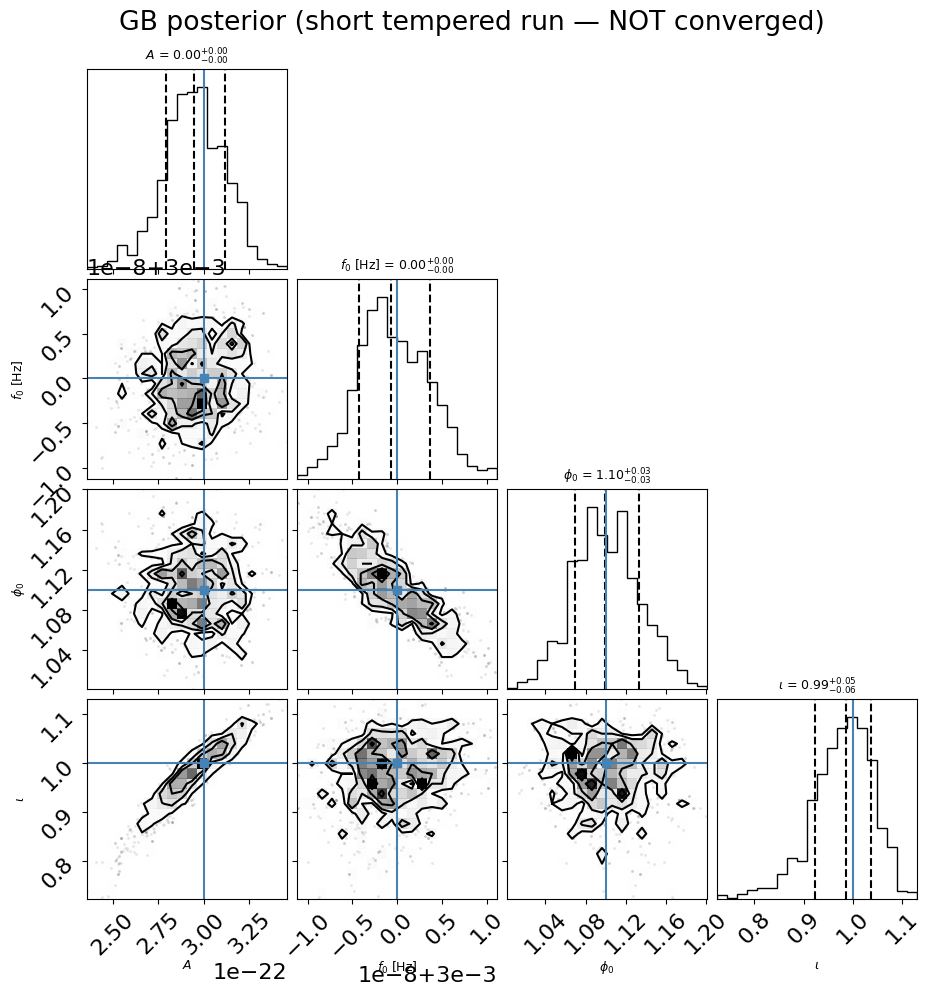

In [9]:
# clear
import corner
labels = [r"$A$", r"$f_0$ [Hz]", r"$\phi_0$", r"$\iota$"]
fig = corner.corner(samples, labels=labels, truths=truth4,
                    show_titles=True, title_kwargs={"fontsize": 9},
                    label_kwargs={"fontsize": 9}, quantiles=[0.16, 0.5, 0.84])
fig.suptitle("GB posterior (short tempered run — NOT converged)", y=1.02)
plt.show()

### Question: GB parameter degeneracies

Look at the corner plot. The frequency $f_0$ and phase $\phi_0$ are pinned
tightly, but $A$ and $\iota$ are broad and *correlated*. Why? What other GB
parameters are degenerate with amplitude and inclination, and what physically
breaks those degeneracies?

*Discussion.* A GB's phase accumulates over the whole observation, so $f_0$ (and
$\phi_0$) are measured extraordinarily well — a sub-bin shift in $f_0$ dephases
the template across $T_\text{obs}$ and destroys the overlap. The **amplitude** and
**inclination**, by contrast, only enter through the two polarization amplitudes:
a nearly face-on ($\iota\to 0$) source is intrinsically louder, so raising $A$ and
tilting $\iota$ trade off along a curved *ridge* of near-constant SNR — the banana
you see. The same information degeneracy couples $A$, $\iota$, the polarization
$\psi$, and the **sky position** $(\lambda,\beta)$ (which set how the two
polarizations project into the XYZ channels and modulate the amplitude over the
year). What breaks them is **the LISA response over time**: the orbital motion
sweeps the antenna pattern, so a longer baseline resolves the sky location and
disentangles the amplitude/inclination/polarization combination. Here we froze
$\psi$, $\lambda$, $\beta$ at the truth and used a short baseline, so only the
residual $A$–$\iota$ ridge is visible.

## Task 5: The pay-off — fast vs direct likelihood timing (Stage E)

Why bother band-limiting? Because scoring the likelihood over the whole data
stream is wasteful when the source only lives in a sliver of it. Here we time the
**fast** (band-limited) likelihood against a **direct** one that generates and
scores the same template on the *full* frequency grid, and confirm the two give
the same value.

The full-grid container is **provided** below (built once, as a real full-grid
analysis would precompute its covariance). Your task: time a single
`eryn_likelihood_function` call on each and report the speed-up.

Useful documentation:
* [`eryn_likelihood_function`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/datacontainer.html#lisatools.analysiscontainer.AnalysisContainer.eryn_likelihood_function)
* Informational notebook: see [`04` &sect; the `AnalysisContainer`](../../04_Foundations.ipynb) and [`X1`](X1_SensitivitySNR.ipynb)

In [10]:
# provided: a DIRECT full-grid likelihood over the whole (Nyquist-limited) band
fd_full = FDSettings(N=injection.shape[-1], df=df,
                     min_freq=1e-4, max_freq=4.9e-2, force_backend="cpu")
data_full = FDSignal(injection.copy(), fd_full)
sens_full = XYZ2SensitivityMatrix(fd_full, model="sangria")

def gb_signal_gen_full(A, f0, phi0, iota):
    params9 = np.array([A, f0, FDOT, 0.0, phi0, iota, PSI, LAM, BETA])
    return FDSignal(gb(params9, Tobs, dt), fd_full)

ac_full = AnalysisContainer(data_full, sens_full, signal_gen=gb_signal_gen_full,
                            likelihood_source_only=True)
print("fast  band bins:", np.asarray(fd_band.f_arr).size)
print("direct full bins:", np.asarray(fd_full.f_arr).size)

fast  band bins: 157
direct full bins: 128188


In [11]:
# clear
# the two likelihoods agree (band captures all the signal)...
print(f"fast   logL(truth) = {ac.eryn_likelihood_function(truth4): .4e}")
print(f"direct logL(truth) = {ac_full.eryn_likelihood_function(truth4): .4e}")

# ...but the fast one is much cheaper. Time a single call each.
def time_call(fn, x, reps=25):
    fn(x)                                   # warm up
    t0 = time.perf_counter()
    for _ in range(reps):
        fn(x)
    return (time.perf_counter() - t0) / reps * 1e3   # ms

t_fast = time_call(ac.eryn_likelihood_function, truth4)
t_direct = time_call(ac_full.eryn_likelihood_function, truth4)
print(f"\nfast   : {t_fast:6.2f} ms / call")
print(f"direct : {t_direct:6.2f} ms / call")
print(f"speed-up: {t_direct / t_fast:.1f}x")

fast   logL(truth) = -0.0000e+00


direct logL(truth) =  8.7311e-11



fast   :   4.79 ms / call
direct :  26.36 ms / call
speed-up: 5.5x


### Question: why does the fast likelihood work?

The fast likelihood gave the *same* number as the direct one but far cheaper.
What did band-limiting exploit, and how does the real **signal-heterodyne** GB
likelihood push the same idea further? Why does this matter for the global fit?

*Discussion.* A GB is confined to a narrow band, so the noise-weighted inner
product $\langle d-h\,|\,d-h\rangle$ picks up essentially all of its value from a
few hundred bins around $f_0$; the rest of the grid contributes only out-of-band
noise that cancels between $d$ and $h$. Scoring on the band therefore costs
$O(\text{band width})$ instead of $O(N)$ — a big win, and it grows with the data
length and the number of sources. **Signal heterodyning** goes further: instead of
scoring against a fixed band it multiplies the data by a *reference* template so
the residual becomes slowly varying, which can then be represented on a *sparse*
grid — making even the template *generation* cheap, and letting one reference serve
a whole neighbourhood of trial parameters. The production GB kernels
(`GBTDIonTheFly` + the C++ signal-het path in
`lisatools/scripts/gb_chunked_het/`) do exactly this. With ~30&thinsp;000 resolvable
GBs and a multi-year data stream, this sparsity is the difference between a global
fit that runs and one that does not.

## Task 6: Reversible jump over the number of sources

So far the model was *fixed*: exactly one GB. Real data contain an **unknown
number** of overlapping sources, and the sampler has to infer that count too.
**Reversible-jump MCMC** (RJ) does this by proposing to *add* or *remove* a source
(a *leaf*) as well as to update the existing ones, so the chain wanders across
models of different dimension; the histogram of the leaf count is a **posterior on
the number of sources**.

We inject **two** GBs in the same band — a *loud* one and a *marginal* one — and
run a short RJ sampler. Because the two GBs overlap in frequency, we build the
combined template by **summing each leaf's buffer explicitly** (the provided
helper): `generate_global_template` accumulates sources correctly only when they
occupy *distinct* bins, so overlapping leaves must be summed by hand. Everything up
to here — data, generator, `AnalysisContainer` — is the same skeleton; RJ only
changes *which moves* the sampler makes.

Useful documentation:
* [`EnsembleSampler`](https://lisa-analysis-tools.github.io/Eryn/user/ensemble.html#eryn.ensemble.EnsembleSampler) (`rj_moves`, `nleaves_max`, `nleaves_min`, `branch_names`) /
  [`GaussianMove`](https://lisa-analysis-tools.github.io/Eryn/user/moves.html#eryn.moves.GaussianMove)
* [`State`](https://lisa-analysis-tools.github.io/Eryn/user/state.html#eryn.state.State) (`inds` / `coords`) /
  [`get_nleaves`](https://lisa-analysis-tools.github.io/Eryn/user/backend.html)
* Informational notebook: see [`07` &sect; Reversible-jump MCMC](../../07_ErynSmallToLarge.ipynb) and [`X5`](X5_RJMCMC.ipynb)

In [12]:
# imports
from eryn.moves import GaussianMove

In [13]:
# provided: a two-GB injection (loud + marginal) and a leaf-summing likelihood.
rfft_len = injection.shape[-1]
f0_a, f0_b = 2.97e-3, 3.03e-3                         # two close GBs
inj_a = (3.5e-22, f0_a, 1.1, 1.0)                    # loud   (SNR ~ 60)
inj_b = (3.9e-23, f0_b, 2.3, 0.9)                    # marginal (SNR ~ 8)
band_rj = (2.94e-3, 3.06e-3)

def _one9(A, f0, phi0, iota):
    return np.array([A, f0, FDOT, 0.0, phi0, iota, PSI, LAM, BETA])

fd_rj = FDSettings(N=rfft_len, df=df, min_freq=band_rj[0], max_freq=band_rj[1],
                   force_backend="cpu")
buf = np.zeros((3, rfft_len), dtype=np.complex128)
for p in (inj_a, inj_b):
    buf += gb(_one9(*p), Tobs, dt)                   # sum sources into the data
data_rj = FDSignal(buf.copy(), fd_rj)
sens_rj = XYZ2SensitivityMatrix(fd_rj, model="sangria")
ac_rj = AnalysisContainer(data_rj, sens_rj, likelihood_source_only=True)

def gb_sum_template(x):
    """Summed band-limited template for x = (n_active_leaves, 4)."""
    x = np.atleast_2d(x)
    b = np.zeros((3, rfft_len), dtype=np.complex128)
    for leaf in x:
        b += gb(_one9(*leaf), Tobs, dt)
    return FDSignal(b, fd_rj)

def log_like_rj(x):
    # Eryn passes the active leaves of one walker as (n_active_leaves, ndim)
    return ac_rj.template_likelihood(gb_sum_template(x))

print(f"two-GB combined SNR = {ac_rj.snr():.1f}")
print("logL(both truths)  =", log_like_rj(np.array([inj_a, inj_b])))

two-GB combined SNR = 64.5
logL(both truths)  = -1.1641532182693481e-10


In [14]:
# clear
# RJ setup: one "gb" branch whose leaf count may vary between 1 and 3
priors_rj = {"gb": ProbDistContainer({
    0: UniformDistribution(1.0e-23, 6.0e-22),           # amplitude A
    1: UniformDistribution(band_rj[0], band_rj[1]),     # frequency f0
    2: UniformDistribution(0.0, 2 * np.pi),             # phase phi0
    3: UniformDistribution(0.2, np.pi - 0.2),           # inclination iota
})}
ntemps, nwalkers = 4, 12
nleaves_max, nleaves_min = {"gb": 3}, {"gb": 1}

# a Gaussian in-model proposal (stretch does not work across changing dimension)
cov = {"gb": np.diag([(3e-23) ** 2, (1e-6) ** 2, 0.05 ** 2, 0.05 ** 2])}

sampler_rj = EnsembleSampler(
    nwalkers, {"gb": 4}, log_like_rj, priors_rj,
    tempering_kwargs=dict(ntemps=ntemps),
    branch_names=["gb"], nleaves_max=nleaves_max, nleaves_min=nleaves_min,
    moves=GaussianMove(cov), rj_moves=True,
)

# warm start: two leaves per walker, near the two injections
coords = {"gb": priors_rj["gb"].rvs(size=(ntemps, nwalkers, nleaves_max["gb"]))}
inds = {"gb": np.zeros((ntemps, nwalkers, nleaves_max["gb"]), dtype=bool)}
inds["gb"][:, :, 0] = inds["gb"][:, :, 1] = True
jit = np.array([1e-23, 1e-7, 0.05, 0.02])
coords["gb"][:, :, 0, :] = np.array(inj_a) + jit * np.random.randn(ntemps, nwalkers, 4)
coords["gb"][:, :, 1, :] = np.array(inj_b) + jit * np.random.randn(ntemps, nwalkers, 4)

sampler_rj.run_mcmc(State(coords, inds=inds), 60, burn=20, progress=False)

Read out the **posterior on the number of sources** from the cold chain's leaf
counts. The strong source is always kept; the marginal one is only sometimes
favoured, so the count is split between 1 and 2 — an honest, unconverged reflection
of how confidently the fainter GB is detected.

count posterior (n_sources -> fraction):
  1: 0.551
  2: 0.439
  3: 0.010


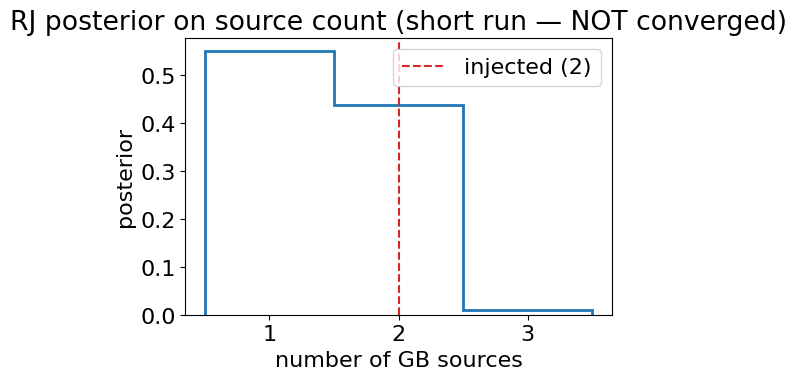

In [15]:
# clear
nleaves = sampler_rj.get_nleaves()["gb"][:, 0].flatten()   # cold chain
counts = np.bincount(nleaves, minlength=4)
print("count posterior (n_sources -> fraction):")
for k in range(1, 4):
    print(f"  {k}: {counts[k] / counts.sum():.3f}")

plt.figure(figsize=(5.5, 3.6))
plt.hist(nleaves, bins=np.arange(0.5, 4.5, 1.0), density=True,
         histtype="step", lw=2, color="C0")
plt.axvline(2, color="C3", ls="--", lw=1.5, label="injected (2)")
plt.xticks([1, 2, 3]); plt.xlabel("number of GB sources"); plt.ylabel("posterior")
plt.title("RJ posterior on source count (short run — NOT converged)")
plt.legend(); plt.show()

### Question: what does RJ over source count mean physically?

The count histogram is a posterior over *how many* GBs are in the data. What is
it really telling us, why is it *split* rather than a spike at 2, and how does the
real global fit find sources this way?

*Discussion.* Each RJ birth/death proposal asks a Bayesian model-comparison
question: *does adding this source improve the fit enough to justify the extra
parameters?* The answer trades the gain in likelihood against the **Occam factor**
— the prior volume a new source must be paid for. For the **loud** GB the gain is
overwhelming, so every walker keeps it; for the **marginal** one (SNR ~ 8) the gain
barely beats the Occam penalty, so the chain keeps it only part of the time and the
count posterior sits between 1 and 2. That split *is* the physics: it quantifies our
confidence that the fainter source is real, exactly the regime at the GB confusion
limit where "is there another binary here?" has no crisp yes/no. Note that RJ
proposals drawn from the *prior* are inefficient — a random draw rarely lands on a
source — which is why we warm-started near the truth and why the production global
fit feeds RJ **informed** proposals from a search/F-statistic rather than the prior.
Scaled up, this same reversible jump is how the global fit decides the resolvable-GB
catalogue while the rest pile into the stochastic confusion foreground.

### Where this goes next

You have now run the full **source-MCMC skeleton** on a galactic binary: data →
band-limited generator (the fast likelihood) → `AnalysisContainer` → tempered
sampling → and a reversible jump over the source count. The other `further/`
source exercises reuse these five stages verbatim and only swap the waveform and
its parameter transforms — an EMRI or an MBHB is *the same sampler with a different
`signal_gen`*. From here, the leap to the full LISA global fit is scale, tuned
proposals, and many source types sharing one data stream, not a new idea about how
the sampler runs (informational notebooks [`07`](../../07_ErynSmallToLarge.ipynb)
and [`02`](../../02_StockGlobalFitsInDepth.ipynb)); dedicated reversible-jump
practice is in [`X5`](X5_RJMCMC.ipynb).